#### Prepared for Gabor's Data Analysis

### Data Analysis for Business, Economics, and Policy
by Gabor Bekes and  Gabor Kezdi
 
Cambridge University Press 2021

**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.

### Chapter 19
**CH19A Food and health**

using the food-health dataset

version 1.0 2021-05-05

In [2]:
import os
import sys
import warnings

import pandas as pd
import statsmodels.formula.api as smf
from IPython.core.display import HTML
from plotnine import *
from stargazer.stargazer import Stargazer

import numpy as np
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


___

In [3]:
# !!! make sure you have run ch19-food-health.ipynb before
data = pd.read_csv("/workspaces/codespaces-jupyter/data/food-health.csv")

In [4]:
data["smoker"]

0        False
1         True
2        False
3         True
4        False
         ...  
16479    False
16480    False
16481    False
16482    False
16483    False
Name: smoker, Length: 16484, dtype: bool

In [5]:
workfile = data.query("age>=30&age<60")

In [6]:
# new variables: 
  ## Fruit and vegetables per day (grams)
  ## Blood pressure (systolic+diastolic)

In [7]:
workfile = workfile.rename(columns={"veggies_n_fruits_gr":"fv","blood_pressure":"bp"})

In [8]:
workfile["fv"].describe()

count    7930.000000
mean      261.058836
std       285.358857
min         0.000000
25%        52.081874
50%       186.840000
75%       378.932500
max      5047.000000
Name: fv, dtype: float64

In [9]:
workfile["bp"].describe()

count    7360.000000
mean      193.708288
std        23.736936
min       129.000000
25%       178.000000
50%       192.000000
75%       208.000000
max       300.000000
Name: bp, dtype: float64

In [10]:
workfile = (
    workfile.loc[workfile["fv"] < 3200].dropna(subset=["bp"]).reset_index(drop=True)
)

In [11]:
# Days per week exercising
workfile["exerc"] = None
workfile.loc[workfile["paq655"] <= 7, "exerc"] = workfile["paq655"]
workfile.loc[workfile["paq650"] == 2, "exerc"] = 0
workfile["exerc"] = pd.to_numeric(workfile["exerc"])

In [12]:
# Potato chips per day, grams
workfile = workfile.rename(columns={"gr_potato_chips": "pchips"})

In [13]:
workfile = workfile.rename(columns={"gr_potato_chips": "pchips"})

### Descriptive table

In [14]:
(
    workfile[["bp", "fv"]]
    .describe()
    .rename(
        columns={
            "bp": "Blood pressure (systolic+diastolic)",
            "fv": "Fruit and vegetables per day (grams)",
        }
    )
    .T.rename(
        columns={
            "50%": "Median",
            "mean": "Mean",
            "count": "Observations",
            "max": "Maximum",
            "min": "Minimum",
            "std": "Std.Dev.",
        }
    )
    .round()
    .astype(int)
    .filter(["Mean", "Median", "Std.Dev.", "Minimum", "Maximum", "Observations"])
)

,Mean,Median,Std.Dev.,Minimum,Maximum,Observations
Blood pressure (systolic+diastolic),194,192,24,129,300,7358
Fruit and vegetables per day (grams),260,188,274,0,2740,7358


In [15]:
workfile_smoking = workfile.copy()
workfile_smoking

,Unnamed: 0,seqn,food_code,days,grams,vitaminc,alcohol,caffeine,cholesterol,year,...,total_cholesterol,hdl,weight,height,ldl,bmi,normal_weight,bp,heart_risk,exerc
0,0,51624.0,13110100.0,1.0,268.25,1.6,0.0,0.0,118.0,2009.0,...,50.0,135.0,87.4,164.7,85.0,32.219903,0,202.0,287.0,0.0
1,3,51630.0,63101000.0,1.0,223.00,10.3,0.0,0.0,0.0,2009.0,...,45.0,259.0,86.7,168.4,214.0,30.572779,0,200.0,414.0,0.0
2,8,51647.0,75500210.0,1.0,42.25,1.0,0.0,0.0,0.0,2009.0,...,82.0,225.0,75.7,166.7,143.0,27.241102,0,168.0,311.0,3.0
3,11,51653.0,75113000.0,1.0,8.00,0.2,0.0,0.0,0.0,2009.0,...,37.0,197.0,102.4,187.6,160.0,29.096067,0,208.0,368.0,0.0
4,13,51655.0,92101000.0,1.0,192.40,0.0,0.0,77.0,0.0,2009.0,...,58.0,202.0,76.5,164.1,144.0,28.408236,0,220.0,364.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7353,16473,83711.0,27560300.0,1.0,176.00,0.9,0.0,0.0,77.0,2013.0,...,43.0,209.0,81.9,156.3,166.0,33.524781,0,186.0,352.0,0.0
7354,16475,83713.0,58123120.0,1.0,70.00,0.2,0.0,0.0,2.0,2013.0,...,47.0,180.0,62.5,162.4,133.0,23.697797,1,184.0,317.0,0.0
7355,16477,83715.0,53209100.0,1.0,105.00,0.0,0.0,6.0,0.0,2013.0,...,51.0,179.0,76.3,170.4,128.0,26.277579,0,192.0,320.0,0.0
7356,16479,83721.0,93401020.0,1.0,150.00,0.0,15.5,0.0,0.0,2013.0,...,55.0,138.0,79.5,176.2,83.0,25.606801,0,178.0,261.0,4.0


In [16]:
(
    workfile_smoking[["bp", "fv"]]
    .describe()
    .rename(
        columns={
            "bp": "Blood pressure (systolic+diastolic)",
            "fv": "Fruit and vegetables per day (grams)",
        }
    )
    .T.rename(
        columns={
            "50%": "Median",
            "mean": "Mean",
            "count": "Observations",
            "max": "Maximum",
            "min": "Minimum",
            "std": "Std.Dev.",
        }
    )
    .round()
    .astype(int)
    .filter(["Mean", "Median", "Std.Dev.", "Minimum", "Maximum", "Observations"])
)

,Mean,Median,Std.Dev.,Minimum,Maximum,Observations
Blood pressure (systolic+diastolic),194,192,24,129,300,7358
Fruit and vegetables per day (grams),260,188,274,0,2740,7358


### SCATTERPLOT AND REGRESSION LINE 

In [17]:
# Blood pressure vs amount of fruit and vegetables
reg = smf.ols("bp ~ fv", data=workfile).fit()
print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:                     bp   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     15.47
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           8.44e-05
Time:                        23:03:48   Log-Likelihood:                -33736.
No. Observations:                7358   AIC:                         6.748e+04
Df Residuals:                    7356   BIC:                         6.749e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    194.7421      0.381    510.939      0.0

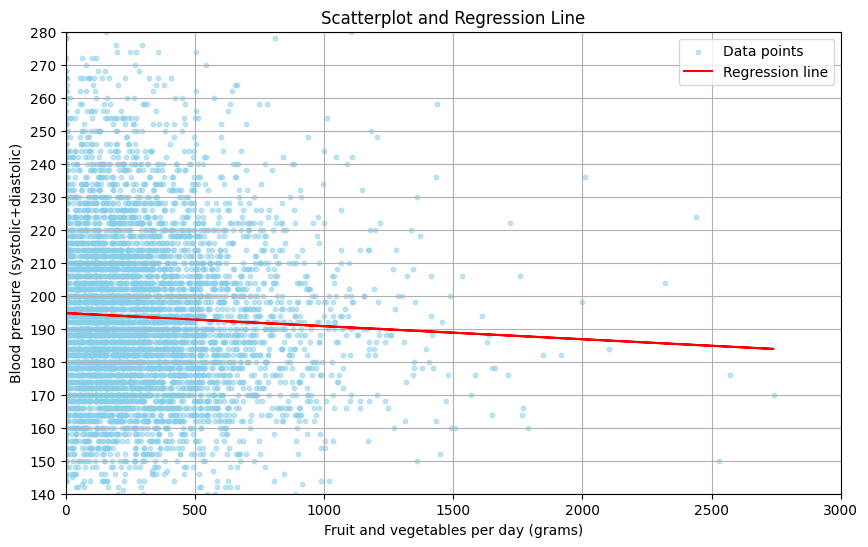

In [18]:
# Extract data
x = workfile["fv"]
y = workfile["bp"]

# Fit a linear regression model
model = LinearRegression()
x_reshaped = x.values.reshape(-1, 1)
model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, alpha=0.5, color="skyblue", label="Data points")
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlim(0, 3000)
plt.ylim(140, 280)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(140, 281, 10))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.title("Scatterplot and Regression Line")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Regression for smokers
reg_smokers = smf.ols("bp ~ fv", data=workfile[workfile["smoker"] == True]).fit()
print("Regression for Smokers:")
print(reg_smokers.summary())

Regression for Smokers:
                            OLS Regression Results                            
Dep. Variable:                     bp   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.311
Date:                Tue, 26 Aug 2025   Prob (F-statistic):              0.252
Time:                        23:03:48   Log-Likelihood:                -8420.2
No. Observations:                1812   AIC:                         1.684e+04
Df Residuals:                    1810   BIC:                         1.686e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    194.6895      0

In [20]:
# Regression for non-smokers
reg_non_smokers = smf.ols("bp ~ fv", data=workfile[workfile["smoker"] == False]).fit()
print("\nRegression for Non-Smokers:")
print(reg_non_smokers.summary())


Regression for Non-Smokers:
                            OLS Regression Results                            
Dep. Variable:                     bp   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     20.50
Date:                Tue, 26 Aug 2025   Prob (F-statistic):           6.08e-06
Time:                        23:03:48   Log-Likelihood:                -25298.
No. Observations:                5546   AIC:                         5.060e+04
Df Residuals:                    5544   BIC:                         5.061e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    194.6745  

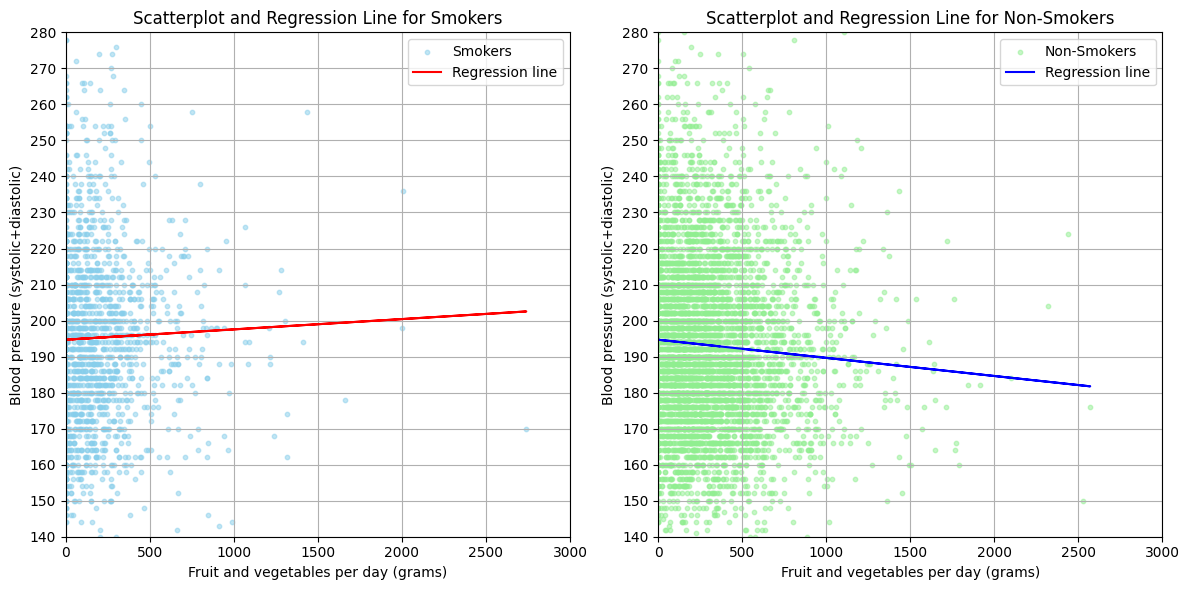

In [21]:
# Filter data for smokers and non-smokers
smokers = workfile[workfile["smoker"] == True]
non_smokers = workfile[workfile["smoker"] == False]

# Extract data for smokers
x_smokers = smokers["fv"]
y_smokers = smokers["bp"]

# Fit a linear regression model for smokers
model_smokers = LinearRegression()
x_smokers_reshaped = x_smokers.values.reshape(-1, 1)
model_smokers.fit(x_smokers_reshaped, y_smokers)
y_smokers_pred = model_smokers.predict(x_smokers_reshaped)

# Extract data for non-smokers
x_non_smokers = non_smokers["fv"]
y_non_smokers = non_smokers["bp"]

# Fit a linear regression model for non-smokers
model_non_smokers = LinearRegression()
x_non_smokers_reshaped = x_non_smokers.values.reshape(-1, 1)
model_non_smokers.fit(x_non_smokers_reshaped, y_non_smokers)
y_non_smokers_pred = model_non_smokers.predict(x_non_smokers_reshaped)

# Create scatterplot and regression line for smokers
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(x_smokers, y_smokers, s=10, alpha=0.5, color="skyblue", label="Smokers")
plt.plot(x_smokers, y_smokers_pred, color="red", label="Regression line")
plt.xlim(0, 3000)
plt.ylim(140, 280)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(140, 281, 10))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.title("Scatterplot and Regression Line for Smokers")
plt.legend()
plt.grid(True)

# Create scatterplot and regression line for non-smokers
plt.subplot(1, 2, 2)
plt.scatter(x_non_smokers, y_non_smokers, s=10, alpha=0.5, color="lightgreen", label="Non-Smokers")
plt.plot(x_non_smokers, y_non_smokers_pred, color="blue", label="Regression line")
plt.xlim(0, 3000)
plt.ylim(140, 280)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(140, 281, 10))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.title("Scatterplot and Regression Line for Non-Smokers")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

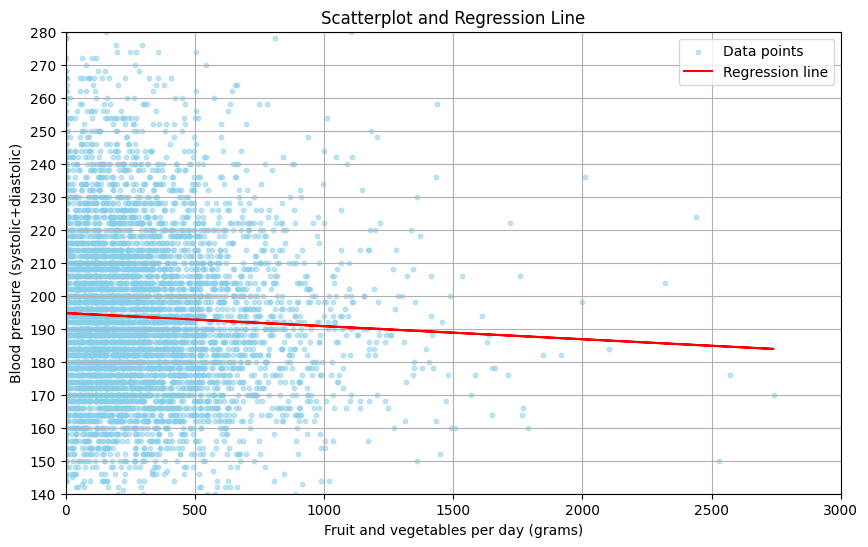

In [25]:
# Extract data
x = workfile["fv"]
y = workfile["bp"]

# Fit a linear regression model
model = LinearRegression()
x_reshaped = x.values.reshape(-1, 1)
model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, alpha=0.5, color="skyblue", label="Data points")
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlim(0, 3000)
plt.ylim(140, 280)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(140, 281, 10))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.title("Scatterplot and Regression Line")
plt.legend()
plt.grid(True)
plt.show()

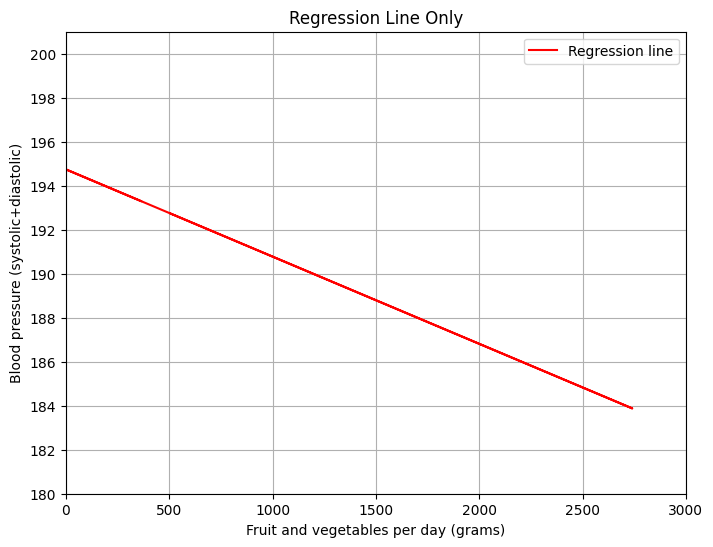

In [ ]:
# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlim(0, 3000)
plt.ylim(180, 201)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(180, 201, 2))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.title("Regression Line Only")
plt.legend()
plt.grid(True)
plt.show()


#### Log household income per capita vs fruit and vegetables per day,grams

In [ ]:
# gen Log household income per capita
workfile["lninc"] = np.log(workfile["hh_income_percap"])

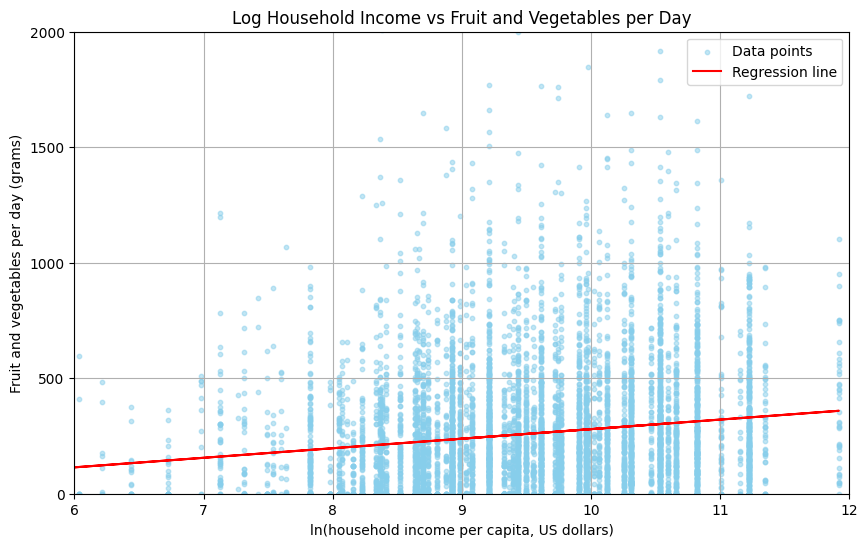

In [ ]:
# Drop NaN values for 'lninc' and 'fv'
filtered_data = workfile.dropna(subset=["lninc", "fv"])

# Extract x and y values
x = filtered_data["lninc"]
y = filtered_data["fv"]

# Fit a linear regression model
model = LinearRegression()
x_reshaped = x.values.reshape(-1, 1)
model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, alpha=0.5, color="skyblue", label="Data points")
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlim(6, 12)
plt.ylim(0, 2000)
plt.xticks(np.arange(6, 13, 1))
plt.yticks(np.arange(0, 2001, 500))
plt.xlabel("ln(household income per capita, US dollars)")
plt.ylabel("Fruit and vegetables per day (grams)")
plt.title("Log Household Income vs Fruit and Vegetables per Day")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Amount of fruit and vegetables per day, g (fv) vs Days per week vigorous recreational activities (exerc)
workfile.groupby("exerc").agg(tab_exerc=("year", "count"))

,tab_exerc
exerc,
0.0,5665
1.0,248
2.0,354
3.0,474
4.0,258
5.0,213
6.0,77
7.0,68


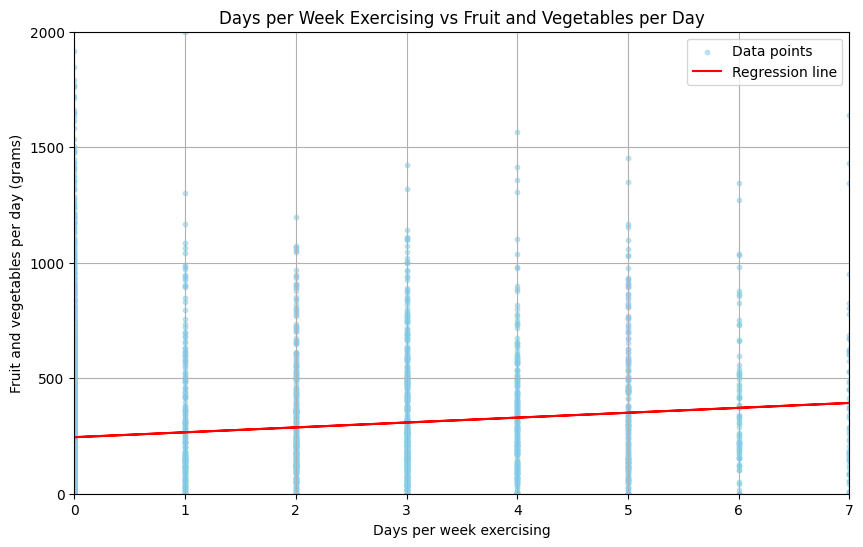

In [ ]:
# Drop NaN values for 'exerc' and 'fv'
filtered_data = workfile.dropna(subset=["exerc", "fv"])

# Extract x and y values
x = filtered_data["exerc"]
y = filtered_data["fv"]

# Fit a linear regression model
model = LinearRegression()
x_reshaped = x.values.reshape(-1, 1)
model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, alpha=0.5, color="skyblue", label="Data points")
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlim(0, 7)
plt.ylim(0, 2000)
plt.xticks(np.arange(0, 8, 1))
plt.yticks(np.arange(0, 2001, 500))
plt.xlabel("Days per week exercising")
plt.ylabel("Fruit and vegetables per day (grams)")
plt.title("Days per Week Exercising vs Fruit and Vegetables per Day")
plt.legend()
plt.grid(True)
plt.show()

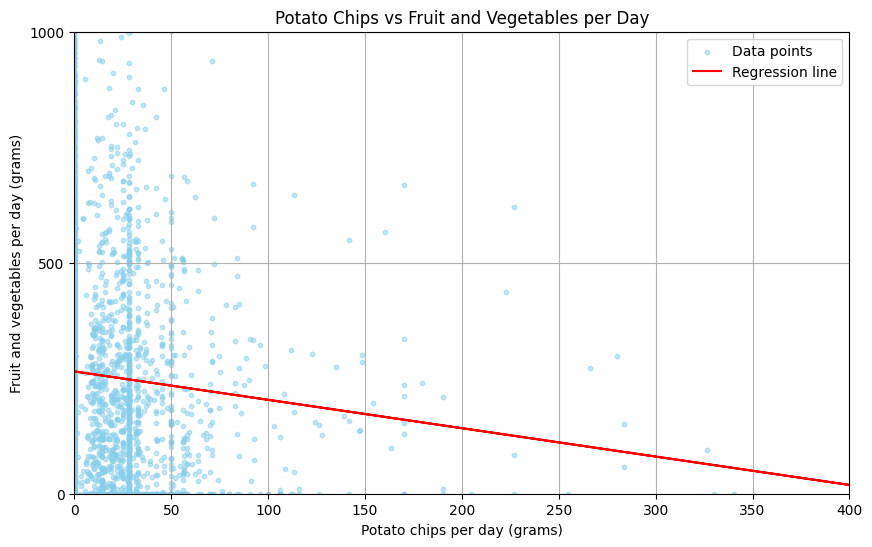

In [ ]:
# Potato chips (pchips) and amount of fruit and vegetables per day (fv)
x = workfile["pchips"]
y = workfile["fv"]

# Fit a linear regression model
model = LinearRegression()
x_reshaped = x.values.reshape(-1, 1)
model.fit(x_reshaped, y)
y_pred = model.predict(x_reshaped)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, alpha=0.5, color="skyblue", label="Data points")
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlim(0, 400)
plt.ylim(0, 1000)
plt.xticks(np.arange(0, 401, 50))
plt.yticks(np.arange(0, 1001, 500))
plt.xlabel("Potato chips per day (grams)")
plt.ylabel("Fruit and vegetables per day (grams)")
plt.title("Potato Chips vs Fruit and Vegetables per Day")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
reg1 = smf.ols("bp ~ fv", data=workfile).fit(cov_type="HC1")
reg2 = smf.ols("fv ~ lninc", data=workfile).fit(cov_type="HC1")
reg3 = smf.ols("fv ~ exerc", data=workfile).fit(cov_type="HC1")
reg4 = smf.ols("fv ~ pchips", data=workfile).fit(cov_type="HC1")

In [ ]:
# Create a summary table for the regression results
summary_data = {
    "Model": ["Model 1", "Model 2", "Model 3", "Model 4"],
    "Dependent Variable": ["bp", "fv", "fv", "fv"],
    "Independent Variable": ["fv", "lninc", "exerc", "pchips"],
    "R-squared": [reg1.rsquared, reg2.rsquared, reg3.rsquared, reg4.rsquared],
    "Adj. R-squared": [reg1.rsquared_adj, reg2.rsquared_adj, reg3.rsquared_adj, reg4.rsquared_adj],
    "F-statistic": [reg1.fvalue, reg2.fvalue, reg3.fvalue, reg4.fvalue],
    "P-value (F-stat)": [reg1.f_pvalue, reg2.f_pvalue, reg3.f_pvalue, reg4.f_pvalue],
}

# Convert the summary data into a DataFrame
summary_table = pd.DataFrame(summary_data)

# Display the summary table
summary_table.round(3)

In [ ]:
stargazer = Stargazer([reg1, reg2, reg3, reg4])
stargazer.covariate_order(["Intercept", "fv", "lninc", "exerc", "pchips"])
stargazer.rename_covariates({"Intercept": "Constant"})
stargazer.custom_columns(["Model 1", "Model 2", "Model 3", "Model 3"], [1, 1, 1, 1])
stargazer.show_model_numbers(False)
HTML(stargazer.render_html())

### Non-parametric regressions

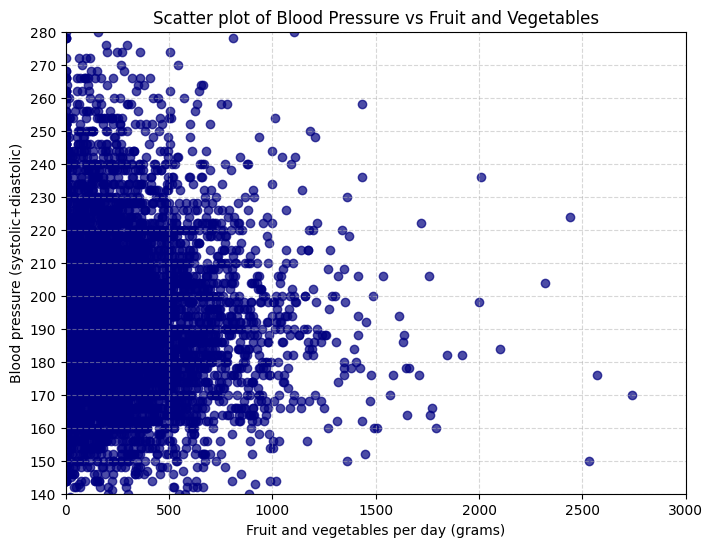

In [32]:
# Scatter plot using Matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(workfile["fv"], workfile["bp"], color="navy", alpha=0.7)
plt.xlim(0, 3000)
plt.ylim(140, 280)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(140, 281, 10))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.title("Scatter plot of Blood Pressure vs Fruit and Vegetables")
plt.show()

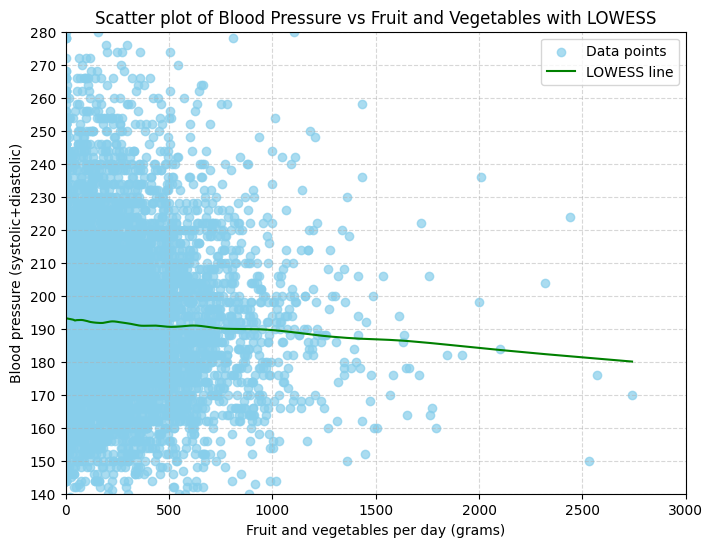

In [35]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# Scatter plot using Matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(workfile["fv"], workfile["bp"], color="skyblue", alpha=0.7, label="Data points")

# Add LOWESS smoothing
lowess_smoothed = lowess(workfile["bp"], workfile["fv"], frac=0.3)
plt.plot(lowess_smoothed[:, 0], lowess_smoothed[:, 1], color="green", label="LOWESS line")

plt.xlim(0, 3000)
plt.ylim(140, 280)
plt.xticks(np.arange(0, 3001, 500))
plt.yticks(np.arange(140, 281, 10))
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.title("Scatter plot of Blood Pressure vs Fruit and Vegetables with LOWESS")
plt.legend()
plt.show()

In [37]:
!pip install pwlf

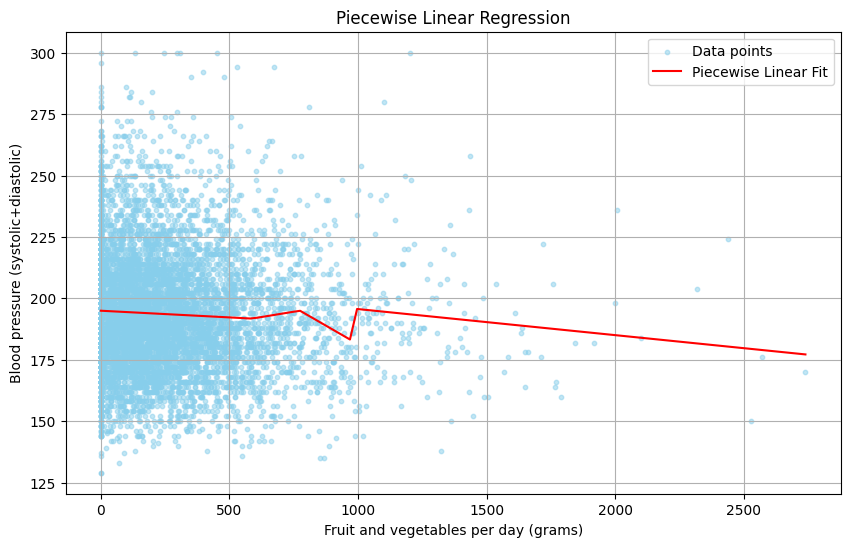

In [39]:
import pwlf

# Extract x and y values
x = workfile["fv"].values
y = workfile["bp"].values

# Fit a piecewise linear regression model
model = pwlf.PiecewiseLinFit(x, y)

# Define the number of breakpoints (e.g., 2 segments)
breakpoints = 5
model.fit(breakpoints)

# Predict y values based on the fitted model
x_hat = np.linspace(min(x), max(x), 100)
y_hat = model.predict(x_hat)

# Plot the data and the piecewise linear regression
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, alpha=0.5, color="skyblue", label="Data points")
plt.plot(x_hat, y_hat, color="red", label="Piecewise Linear Fit")
plt.xlabel("Fruit and vegetables per day (grams)")
plt.ylabel("Blood pressure (systolic+diastolic)")
plt.title("Piecewise Linear Regression")
plt.legend()
plt.grid(True)
plt.show()